## Example of graph extraction and comparison

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd        
from math import sqrt
import networkx as nx
import adjmatrix

In [47]:

def str2list(string):
    array = list(np.fromstring(string[1:-1], dtype=int, sep=','))
    return array 


In [48]:
concr_data = pd.read_excel('branch_statistics_prunned.xlsx')
concr_data.head(20)

,image,threshold,grain_number,index,branch_distance,branch_type,connected_segments,mean_pixel_value,stdev_pixel_value,min_value,median_value,middle_value,basename
0,1,above,0,0,17.549375,1,"[1, 2]",0.584374,0.052023,0.486352,0.593399,0.593399,dataset
1,1,above,0,1,32.197811,2,"[0, 2, 5, 6]",0.509278,0.176188,0.195128,0.486341,0.219450,dataset
2,1,above,0,2,8.453958,2,"[0, 1, 3, 4]",0.420239,0.117107,0.291445,0.395712,0.300283,dataset
3,1,above,0,3,12.527759,1,"[2, 4]",0.528812,0.050257,0.405321,0.542555,0.524093,dataset
4,1,above,0,4,10.574635,1,"[2, 3]",0.351467,0.077053,0.245424,0.348985,0.276632,dataset
5,1,above,0,5,17.075468,2,"[1, 6, 7, 8]",0.431125,0.110349,0.295394,0.402494,0.351081,dataset
6,1,above,0,6,6.096328,1,"[1, 5]",0.622101,0.049290,0.526670,0.634884,0.649803,dataset
7,1,above,0,7,5.287317,1,"[5, 8]",0.567031,0.043086,0.486558,0.578571,0.596411,dataset
8,1,above,0,8,10.407083,1,"[5, 7]",0.616719,0.033032,0.548441,0.626000,0.643384,dataset
9,100,above,0,0,14.076379,1,"[1, 2]",0.579002,0.044063,0.492101,0.577392,0.599994,dataset


### We choose two skeletons

In [ ]:

first_image = concr_data[concr_data["image"] == 35]
first_grain = first_image[first_image["grain_number"] == 0]

second_image = concr_data[concr_data["image"] == 100]
second_grain = second_image[second_image["grain_number"] == 0]


In [ ]:
#info needed for the graph extraction

seg_index1=first_grain["index"] 
connected_branches1=first_grain["connected_segments"]
seg_type1=first_grain["branch_type"].tolist()

seg_index2=second_grain["index"] 
connected_branches2=second_grain["connected_segments"]
seg_type2=second_grain["branch_type"].tolist()

array_connected_branches1 = [str2list(connected_branches1[index]) for index in connected_branches1.index]
array_connected_branches2 = [str2list(connected_branches2[index]) for index in connected_branches2.index] 

The process_segments function transform the info in the datasheet to ajn edges_to_noides dictionary, which give us the nodes corresponding to each skeleton edge


In [49]:
#   cute the main function
edge_to_nodes1 = adjmatrix.process_segments(array_connected_branches1, seg_type1)
edge_to_nodes2 = adjmatrix.process_segments(array_connected_branches2, seg_type2)

print(edge_to_nodes1)
print(edge_to_nodes2)


{0: [4, 1], 1: [4, 2], 2: [4, 3]}
{0: [4, 1], 1: [4, 2], 2: [4, 3]}


Add the edges weight to each branch information

In [50]:

weigths1=first_grain["branch_distance"] 
weigths2=second_grain["branch_distance"]

m = len(edge_to_nodes1)
m2 = len(edge_to_nodes2)
list_nx1=[]
list_nx2=[]
for i in range(m):
    n1,n2 = edge_to_nodes1[i]
    list_nx1.append((n1,n2,weigths1[weigths1.index[i]]))
for i in range(m2):
    n1,n2 = edge_to_nodes2[i]
    list_nx2.append((n1,n2,weigths2[weigths2.index[i]]))
print(list_nx1)
print(list_nx2)



[(4, 1, 63.92171467511877), (4, 2, 8.858463537367971), (4, 3, 20.07455720795211)]
[(4, 1, 14.07637864806765), (4, 2, 23.10239380019141), (4, 3, 69.71168678131512)]


Create the graph

In [51]:
Gw1 = nx.Graph()
Gw1.add_weighted_edges_from(list_nx1)
AM1= nx.adjacency_matrix(Gw1).toarray()

Gw2 = nx.Graph()
Gw2.add_weighted_edges_from(list_nx2)
AM2= nx.adjacency_matrix(Gw2).toarray()

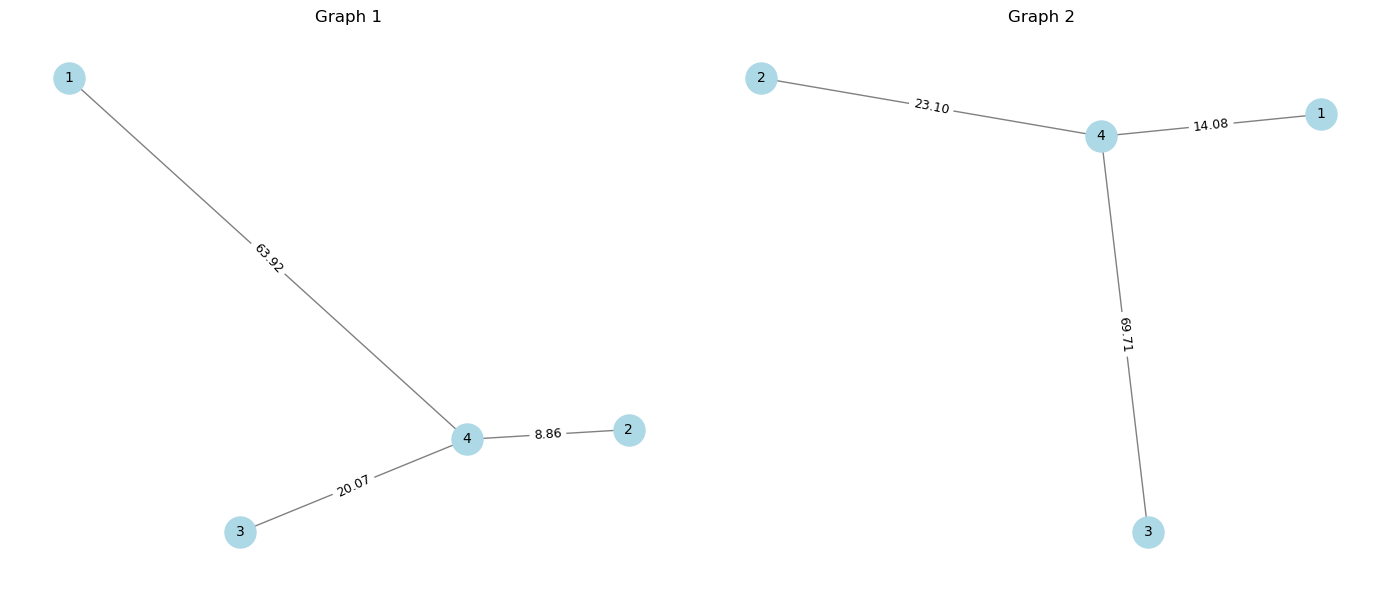

In [52]:
# Create ONE figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------
# Graph 1
# -------------------
pos1 = nx.kamada_kawai_layout(Gw1, weight='weight')

nx.draw(
    Gw1, pos1,
    with_labels=True,
    node_color='lightblue',
    edge_color='gray',
    node_size=500,
    font_size=10,
    ax=axes[0]
)

edge_labels1 = {(u, v): f"{d['weight']:.2f}" 
                for u, v, d in Gw1.edges(data=True)}

nx.draw_networkx_edge_labels(
    Gw1, pos1,
    edge_labels=edge_labels1,
    font_size=9,
    ax=axes[0]
)

axes[0].set_title("Graph 1")
axes[0].axis("off")

# -------------------
# Graph 2
# -------------------
pos2 = nx.kamada_kawai_layout(Gw2, weight='weight')

nx.draw(
    Gw2, pos2,
    with_labels=True,
    node_color='lightblue',
    edge_color='gray',
    node_size=500,
    font_size=10,
    ax=axes[1]
)

edge_labels2 = {(u, v): f"{d['weight']:.2f}" 
                for u, v, d in Gw2.edges(data=True)}

nx.draw_networkx_edge_labels(
    Gw2, pos2,
    edge_labels=edge_labels2,
    font_size=9,
    ax=axes[1]
)

axes[1].set_title("Graph 2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### are they isomorphic?


In [53]:
tf = nx.is_isomorphic(Gw1, Gw2, node_match=None, edge_match=None)
print(tf)

True


Now, we want the best node assigment to minimize the distance between graphs

In [56]:

min_cost, best_AM2, best_perm = adjmatrix.find_adj_matrix_exact_pattern(AM1, AM2, tol=1e-12, max_isomorphisms=None, refine_node_signature=True)
print(AM1)
print(best_AM2)

NEW_g1 = nx.from_numpy_array(AM1)
NEW_g2 = nx.from_numpy_array(best_AM2)

[[ 0.         63.92171468  8.85846354 20.07455721]
 [63.92171468  0.          0.          0.        ]
 [ 8.85846354  0.          0.          0.        ]
 [20.07455721  0.          0.          0.        ]]
[[ 0.         69.71168678 14.07637865 23.1023938 ]
 [69.71168678  0.          0.          0.        ]
 [14.07637865  0.          0.          0.        ]
 [23.1023938   0.          0.          0.        ]]


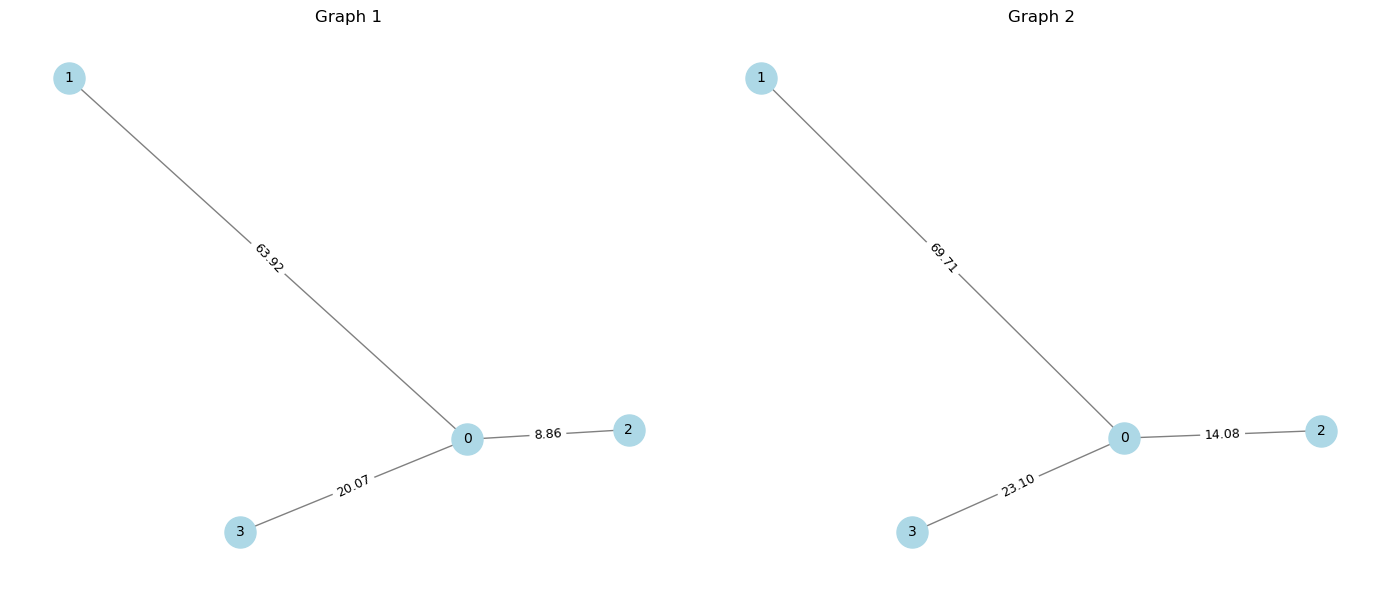

In [57]:
# Create ONE figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------
# Graph 1
# -------------------
pos1 = nx.kamada_kawai_layout(NEW_g1, weight='weight')

nx.draw(
    NEW_g1, pos1,
    with_labels=True,
    node_color='lightblue',
    edge_color='gray',
    node_size=500,
    font_size=10,
    ax=axes[0]
)

edge_labels1 = {(u, v): f"{d['weight']:.2f}" 
                for u, v, d in NEW_g1.edges(data=True)}

nx.draw_networkx_edge_labels(
    NEW_g1, pos1,
    edge_labels=edge_labels1,
    font_size=9,
    ax=axes[0]
)

axes[0].set_title("Graph 1")
axes[0].axis("off")

# -------------------
# Graph 2
# -------------------
pos2 = nx.kamada_kawai_layout(NEW_g2, weight='weight')

nx.draw(
    NEW_g2, pos2,
    with_labels=True,
    node_color='lightblue',
    edge_color='gray',
    node_size=500,
    font_size=10,
    ax=axes[1]
)

edge_labels2 = {(u, v): f"{d['weight']:.2f}" 
                for u, v, d in NEW_g2.edges(data=True)}

nx.draw_networkx_edge_labels(
    NEW_g2, pos2,
    edge_labels=edge_labels2,
    font_size=9,
    ax=axes[1]
)

axes[1].set_title("Graph 2")
axes[1].axis("off")

plt.tight_layout()
plt.show()